In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.shape

(918, 12)

In [ ]:

df.columns


Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


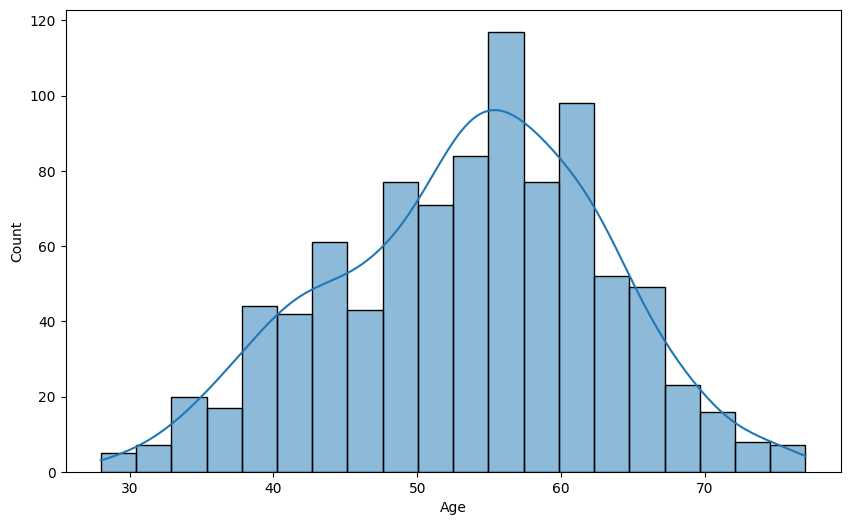

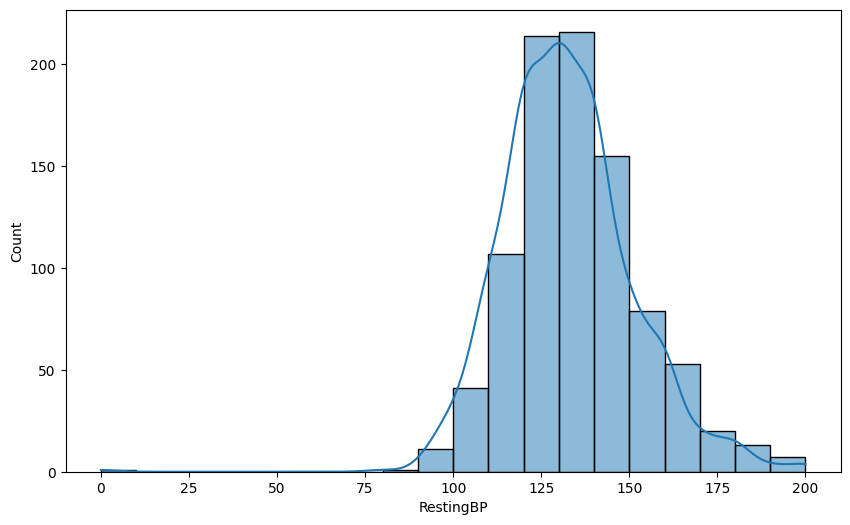

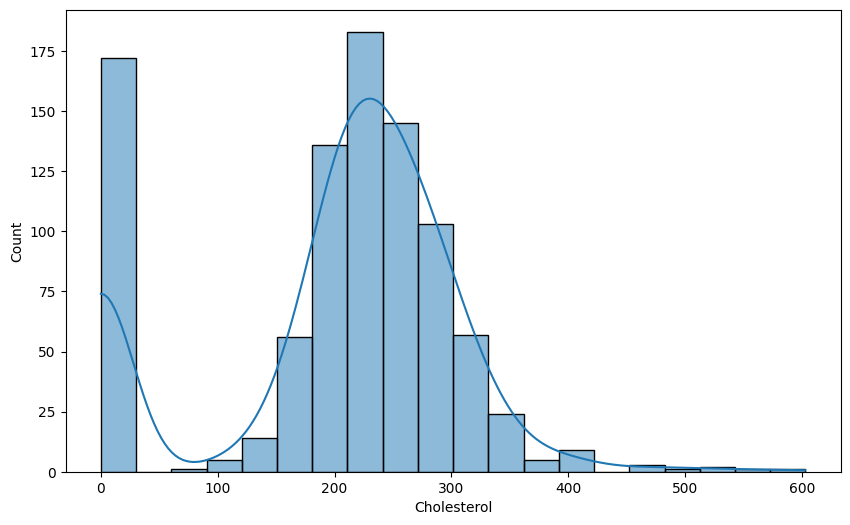

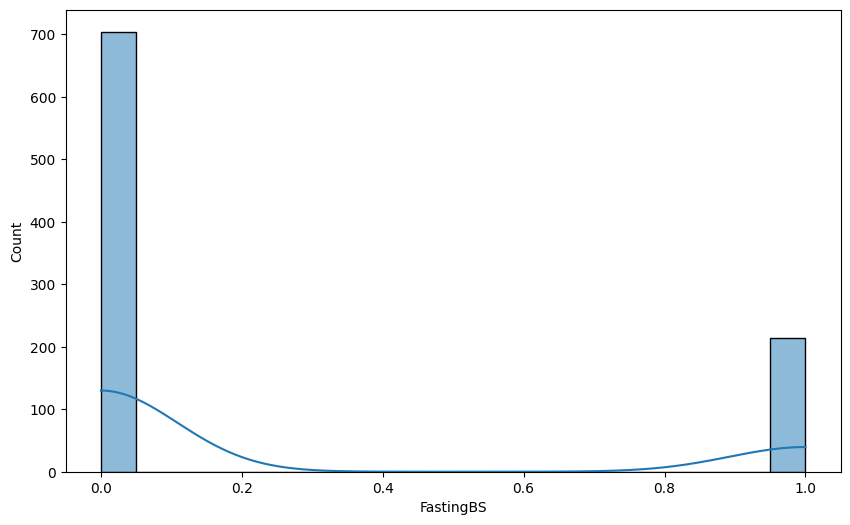

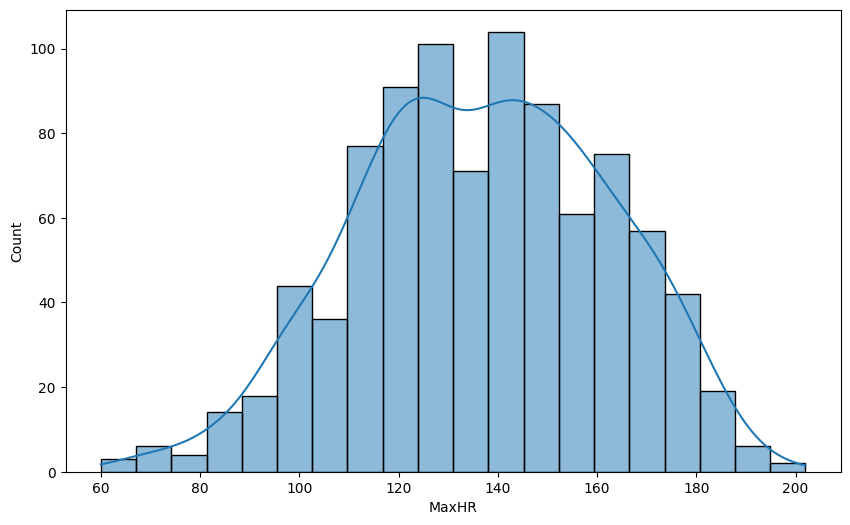

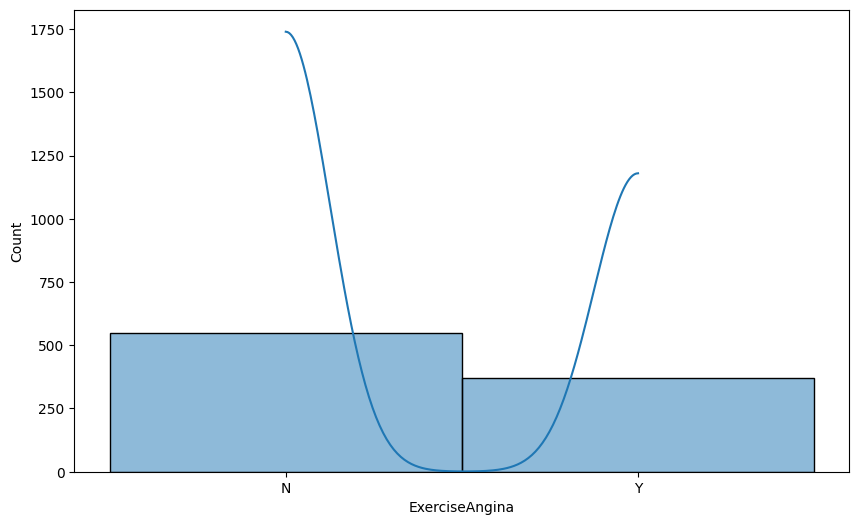

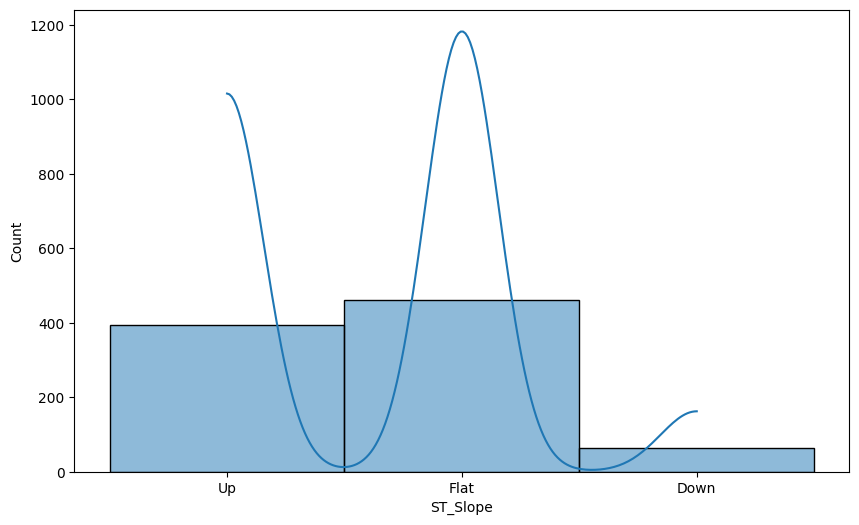

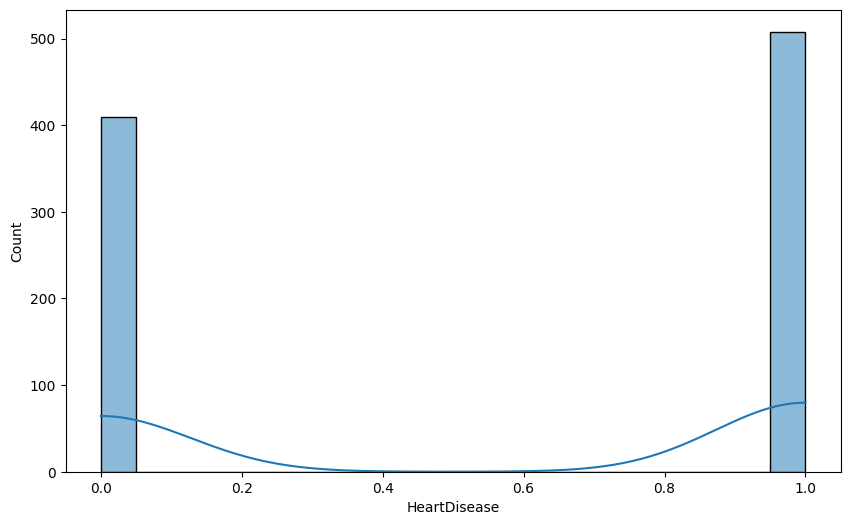

In [ ]:
numeric_col = ['Age','RestingBP','Cholesterol','FastingBS','MaxHR','ExerciseAngina','ST_Slope','HeartDisease']

for col in numeric_col:
  plt.figure(figsize=(10,6))
  sns.histplot(df[col] , kde=True, bins=20)

<Axes: xlabel='Sex', ylabel='count'>

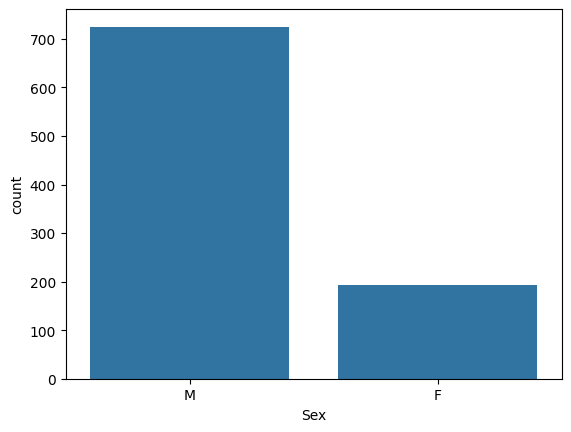

In [ ]:
sns.countplot(x = df['Sex'])

<Axes: xlabel='RestingECG', ylabel='count'>

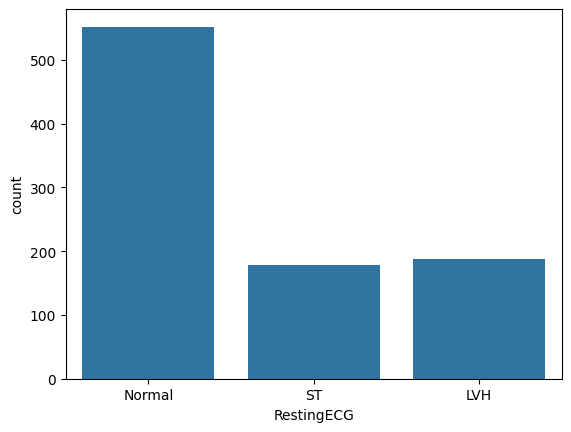

In [ ]:
sns.countplot(x=df['RestingECG'])

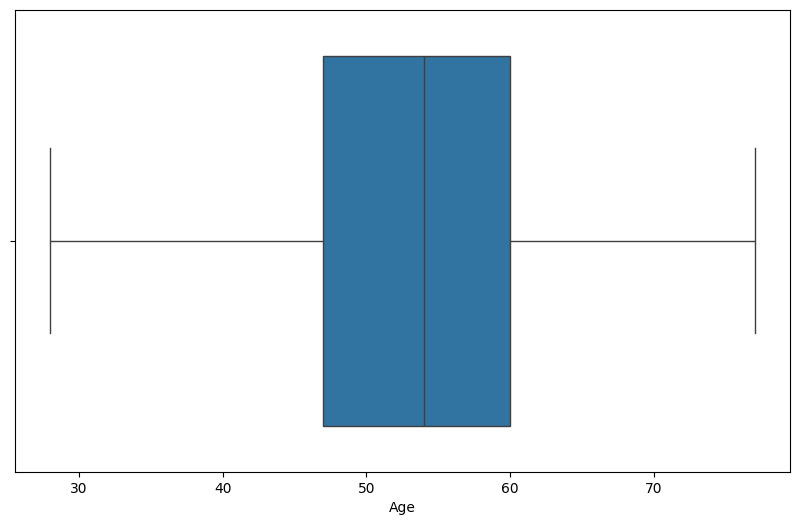

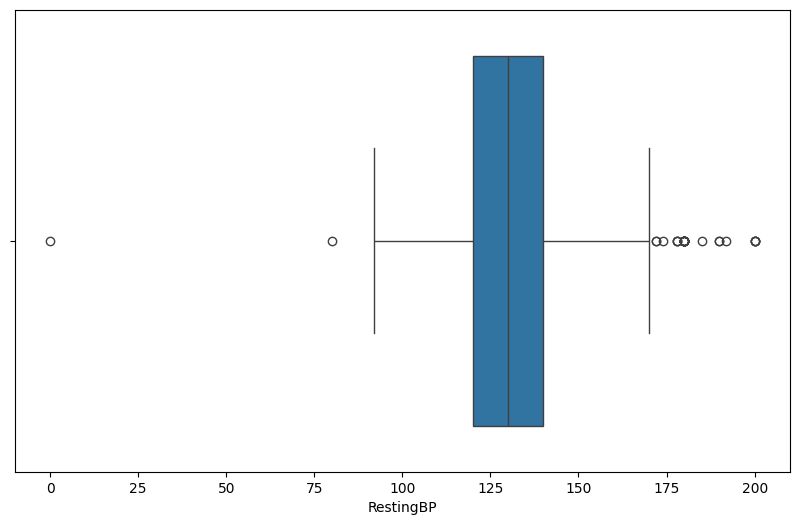

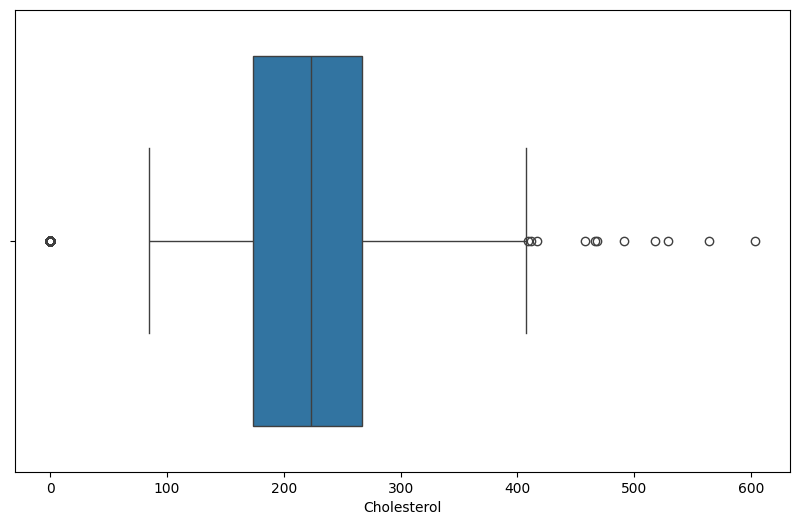

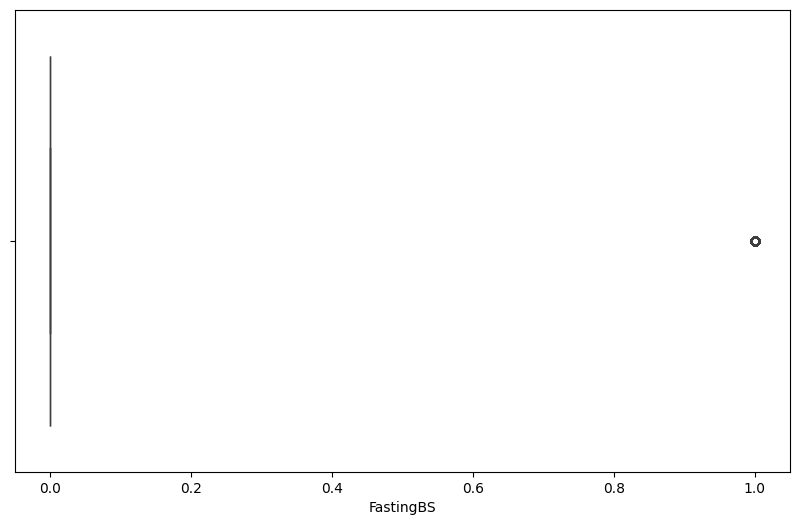

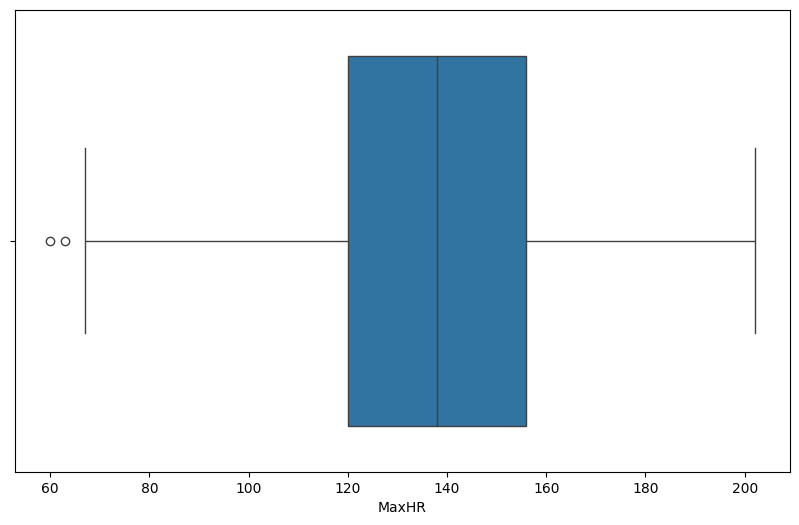

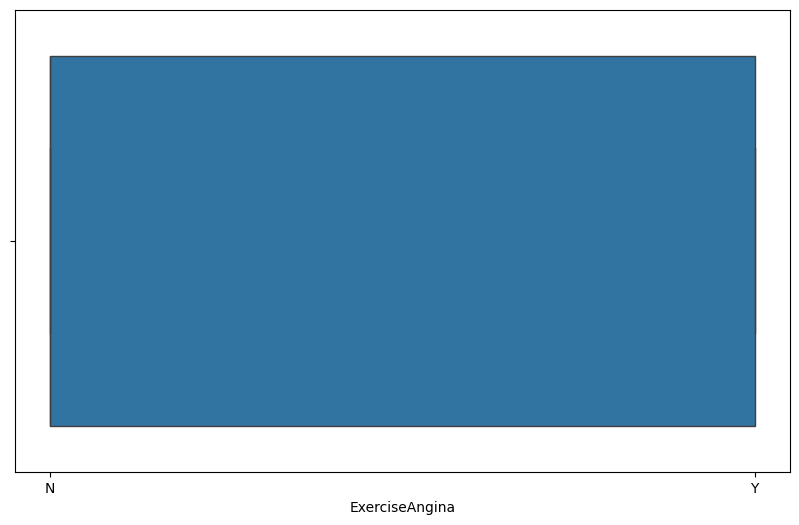

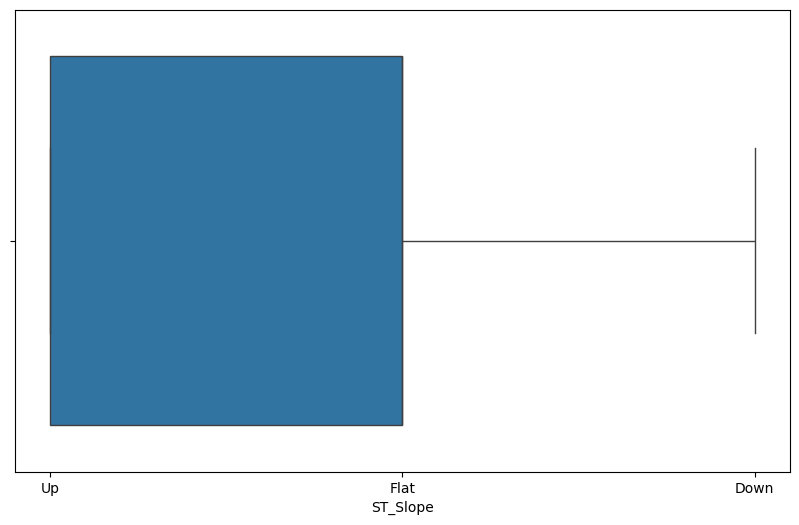

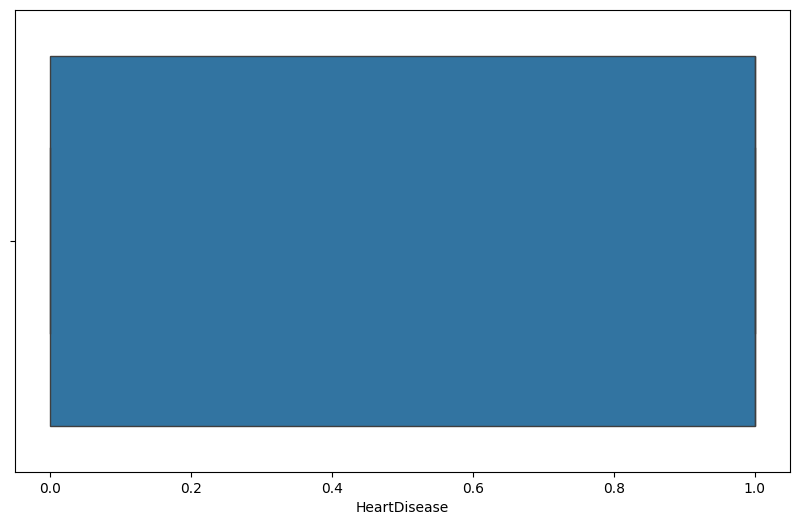

In [ ]:
for col in numeric_col:
  plt.figure(figsize=(10,6))
  sns.boxplot(x = df[col])

<Axes: >

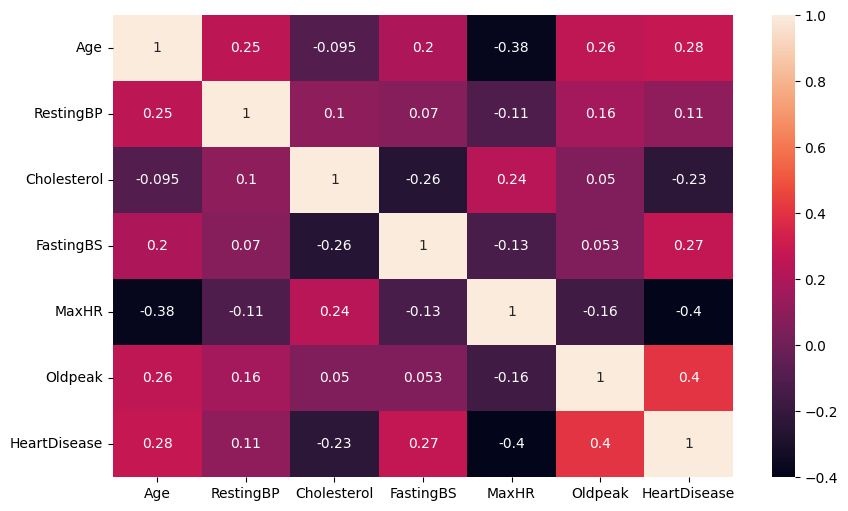

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
df_new = df.copy()
df_new

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
df_new.drop_duplicates(inplace=True)
df_new.shape

(918, 12)

In [ ]:
print(df_new['Sex'].value_counts())
print(df_new['ChestPainType'].value_counts())
print(df_new['RestingECG'].value_counts())
print(df_new['ExerciseAngina'].value_counts())
print(df_new['ST_Slope'].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [ ]:
#label encoding
df_new['Sex'] = df['Sex'].map({'M':0 , 'F':1})
df_new['ExerciseAngina'] = df['ExerciseAngina'].map({'N':1 , 'Y':0})

df_new.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,1,0.0,Up,0
1,49,1,NAP,160,180,0,Normal,156,1,1.0,Flat,1
2,37,0,ATA,130,283,0,ST,98,1,0.0,Up,0
3,48,1,ASY,138,214,0,Normal,108,0,1.5,Flat,1
4,54,0,NAP,150,195,0,Normal,122,1,0.0,Up,0


In [ ]:

df_new = pd.get_dummies(df_new,columns=['ChestPainType'],drop_first=True , dtype = float)

df_new = pd.get_dummies(df_new,columns=['RestingECG'],drop_first=True , dtype = float)

df_new = pd.get_dummies(df_new,columns=['ST_Slope'],drop_first=True , dtype = float)

df_new.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,1,0.0,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,49,1,160,180,0,156,1,1.0,1,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,37,0,130,283,0,98,1,0.0,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,48,1,138,214,0,108,0,1.5,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54,0,150,195,0,122,1,0.0,0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
df_new.rename(columns={'Sex':'Gender'}, inplace=True)
df_new.head()

,Age,Gender,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,1,0.0,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,49,1,160,180,0,156,1,1.0,1,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,37,0,130,283,0,98,1,0.0,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,48,1,138,214,0,108,0,1.5,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54,0,150,195,0,122,1,0.0,0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
df_new = df_new.astype(int)
df_new

,Age,Gender,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,1,0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,1,1,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,1,0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,0,1,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,1,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,1,1,1,0,0,1,1,0,1,0
914,68,0,144,193,1,141,1,3,1,0,0,0,1,0,1,0
915,57,0,130,131,0,115,0,1,1,0,0,0,1,0,1,0
916,57,1,130,236,0,174,1,0,1,1,0,0,0,0,1,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
col = ['Age','Gender','MaxHR','RestingBP','Cholesterol','FastingBS','Oldpeak']
df_new[col] = scaler.fit_transform(df_new[col])

df_new

,Age,Gender,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,-0.515952,0.410909,0.825070,-0.551341,1.382928,1,-0.727592,0,1,0,0,1,0,0,1
1,-0.478484,1.938163,1.491752,-0.171961,-0.551341,0.754157,1,0.282891,1,0,1,0,1,0,1,0
2,-1.751359,-0.515952,-0.129513,0.770188,-0.551341,-1.525138,1,-0.727592,0,1,0,0,0,1,0,1
3,-0.584556,1.938163,0.302825,0.139040,-0.551341,-1.132156,0,0.282891,1,0,0,0,1,0,1,0
4,0.051881,-0.515952,0.951331,-0.034755,-0.551341,-0.581981,1,-0.727592,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-0.515952,-1.210356,0.596393,-0.551341,-0.188999,1,0.282891,1,0,0,1,1,0,1,0
914,1.536902,-0.515952,0.627078,-0.053049,1.813758,0.164684,1,2.303858,1,0,0,0,1,0,1,0
915,0.370100,-0.515952,-0.129513,-0.620168,-0.551341,-0.857069,0,0.282891,1,0,0,0,1,0,1,0
916,0.370100,1.938163,-0.129513,0.340275,-0.551341,1.461525,1,-0.727592,1,1,0,0,0,0,1,0


In [ ]:
df_new.columns

Index(['Age', 'Gender', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [ ]:
from scipy.stats import pearsonr
import pandas as pd

selected_columns = ['Age', 'Gender', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal','RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


corelation = {
     feature:pearsonr(df_new[feature],df_new['HeartDisease'])[0]
     for feature in selected_columns
}

coorelation_df = pd.DataFrame(list(corelation.items()),columns=['feature','pearson corealtion'])
coorelation_df.sort_values(by='pearson corealtion',ascending=False)

,feature,pearson corealtion
13,ST_Slope_Flat,0.554134
7,Oldpeak,0.392385
0,Age,0.282039
4,FastingBS,0.267291
2,RestingBP,0.107589
12,RestingECG_ST,0.102527
10,ChestPainType_TA,-0.054790
11,RestingECG_Normal,-0.091580
9,ChestPainType_NAP,-0.212964
3,Cholesterol,-0.232741


In [ ]:
from scipy.stats import chi2_contingency

selectd_cat =[
    'Gender', 'FastingBS', 'ExerciseAngina', 'Age',
    'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
    'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up'
]

alpha = 0.05
chi2_results = {}

for col in selectd_cat:
    contingency = pd.crosstab(df_new[col],df_new['HeartDisease'])
    chi2_stat,p_val,_,_ = chi2_contingency(contingency)
    decision = decision = 'Reject Null (keep Feature)' if p_val < alpha else 'Accpet Null (drop feature)'

    chi2_results[col]={
        'chi2_stat' : chi2_stat,
        "p_val" : p_val,
        'decision' : decision
    }


chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by="p_val")
chi2_df

,chi2_stat,p_val,decision
ST_Slope_Up,352.823905,0.0,Reject Null (keep Feature)
ST_Slope_Flat,279.659914,0.0,Reject Null (keep Feature)
ExerciseAngina,222.259383,0.0,Reject Null (keep Feature)
ChestPainType_ATA,146.236323,0.0,Reject Null (keep Feature)
Gender,84.145101,0.0,Reject Null (keep Feature)
FastingBS,64.320679,0.0,Reject Null (keep Feature)
ChestPainType_NAP,40.608711,0.0,Reject Null (keep Feature)
Age,125.365667,0.0,Reject Null (keep Feature)
RestingECG_ST,9.135266,0.002507,Reject Null (keep Feature)
RestingECG_Normal,7.327532,0.006791,Reject Null (keep Feature)


In [ ]:
final_df = df_new[['ST_Slope_Up','ST_Slope_Flat','ExerciseAngina','ChestPainType_ATA','Gender','FastingBS','ChestPainType_NAP','Age','RestingECG_ST','RestingECG_Normal']]


final_df.to_csv('heart_cleaned.csv')

In [ ]:
final_df

,ST_Slope_Up,ST_Slope_Flat,ExerciseAngina,ChestPainType_ATA,Gender,FastingBS,ChestPainType_NAP,Age,RestingECG_ST,RestingECG_Normal
0,1,0,1,1,-0.515952,-0.551341,0,-1.433140,0,1
1,0,1,1,0,1.938163,-0.551341,1,-0.478484,0,1
2,1,0,1,1,-0.515952,-0.551341,0,-1.751359,1,0
3,0,1,0,0,1.938163,-0.551341,0,-0.584556,0,1
4,1,0,1,0,-0.515952,-0.551341,1,0.051881,0,1
...,...,...,...,...,...,...,...,...,...,...
913,0,1,1,0,-0.515952,-0.551341,0,-0.902775,0,1
914,0,1,1,0,-0.515952,1.813758,0,1.536902,0,1
915,0,1,0,0,-0.515952,-0.551341,0,0.370100,0,1
916,0,1,1,1,1.938163,-0.551341,0,0.370100,0,0
